## 통계적 가설검정
### 가설검정의 개념

#### 가설검정이란?
**(1) 가설검정의 정의**
- 모집단의 특정에 대한 주장을 가설로 세우고 표본조사로 가설의 채택여부를 결정하는 과정

**(2) 가설의 종류**
- 귀무가설(H0): 일반적으로 생각하는 가설
- 대립가설(H1): 귀무가설을 기각하는 가설, 증명하고자 하는 가설

**(3) 유의수준, 유의확률**
- 유의 수준(α): 귀무가설이 참일 때 기각하는 1종 오류를 범할 확률의 허용 한계(일반적 0.05)
- 유의확률(p-value): 귀무가설을 지지하는 정도를 나타내는 확률
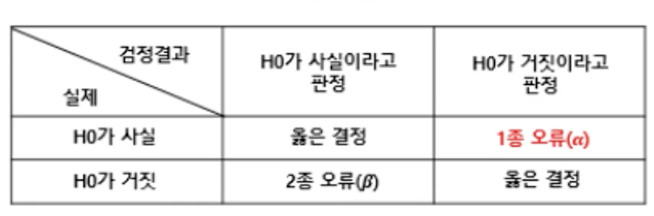

기본: α = 0.05(5%)
- p-value < α : 귀무가설 기각
- p-value > α : 귀무가설 채택

**(4) 기각역과 채택역**
- 검정통계량: 귀무가설의 참과 거짓을 판단하기 위해 사용하는 통계적 계산값
- 기각역: 검정통계랑이 이 범위 안에 들어오면, 귀무가설을 기각하는 영역
- 채택역: 검정통계량이 이 범위 안에 들어오면, 귀무가설을 기각하지 않고 유지

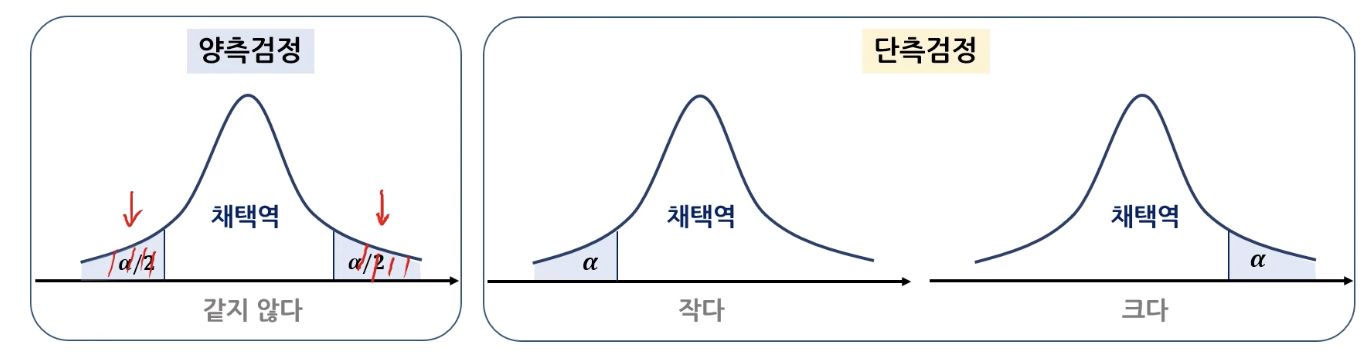

### 대표적인 검정 기법
| 검정 방법 | 사용 조건 | 사례 | 함수 |
| ------- | ------ | ---- | ---- |
| 단일 표본 t-검정 | 모평균과 특정 값의 차이 검정 | 어떤 제품의 평균 길이가 설계값과 동일한지 검정 | ttest_1samp| 
| 독립 표본 t-검정 | 두 집단의 평균 비교, 표본간 독립 | 남녀의 평균 시험점수 비교 | ttest_ind |
| 대응 표본 t-검정 | 같은 집단의 사전/사후 평균 비교, 표본 간 대응 관계 | 교육 전후 동일 학생의 성적 변화 | ttest_rel|
| F 검정 | 두 집단의 분산 비교 | 남녀의 키 분산 차이 비교 | 직접 계산(분산비) |
| 분산분석(ANOVA) | 세 집단 이상 평균 비교 | 세 지역의 평균 매출 비교 | f_oneway |
| 적합도 검정 | 관측분포가 기대분포와 일치하는지 검정 | 주사위 눈금 분포의 균일성 검증 | chisquare | 
| 독립성 검정 | 범주형 변수 간 독립 여부 검정 | 성별과 흡연 여부의 독립성 검정 | chi2_contingency | 
| 동질성 검정 | 여러 모집단에서 범주형 비율이 동일한지 검정 | 지역별 제품 선호도 차이 검정 | chi2_contingency |

### 단일 표본 t-검정
사례) A 공장에서 생산하는 제품의 평균 길이가 150cm 인지 알아보고자 한다. 이를 위해 무작위로 30개의 제품 길이(cm)를 측정한 결과는 다음과 같다. 

In [3]:
import pandas as pd

df = pd.DataFrame({
    'product': [153, 152, 154, 151, 155, 152, 153, 151, 154, 152,
                153, 152, 154, 153, 152, 151, 155, 154, 152, 153,
                152, 153, 151, 154, 152, 153, 152, 155, 154, 152]
})

#### (1) 통계적 가설 설정
- 귀무가설(H0): μ = 150 (제품 평균 길이는 150cm 이다)
- 대립가설(H1): μ ≠ 150 (제품 평균 길이는 150cm가 아니다) → 양측검정

#### (2) 유의수준 결정
유의 수준 α = 0.05

#### (3) 양측검정(기본값 alternative='two-sided')

In [8]:
from scipy import stats # 통계

t_stat, p_value = stats.ttest_1samp(df['product'], 150)
print("t_statistic(검정통계량): ", t_stat)
print("p-value: ", p_value)

t_statistic(검정통계량):  12.623964748893659
p-value:  2.6186124572308594e-13


#### (4) 결과도출
- t-statistic과 p-value를 확인하고, p-value < 0.05 이면 귀무가설 기각
```
t_statistic(검정통계량):  12.623964748893659
p-value:  2.6186124572308594e-13 # 10의 -13승
```
> 해석: 유의수준 0.05에서 p-value가 2.51e-13 이므로, 귀무가설을 기각 → 평균이 150cm라 볼 수 없다

#### (5) 단측검정(>)
- 귀무가설(H0): μ = 150 (제품 평균 길이는 150cm 이다)
- 대립가설(H1): μ > 150 (제품 평균 길이는 150cm 보다 크다)

In [13]:
t_statistic, p_value = stats.ttest_1samp(df['product'], 150, alternative='greater')
print(p_value > 0.05)

False


- 해석: 유의수준 0.05에서 p-value가 작으므로, 귀무가설을 기각 -> 평균이 150cm 보다 크다

#### (6) 단측검정(<)
- 귀무가설(H0): μ = 150 (제품 평균 길이는 150cm 이다)
- 대립가설(H1): μ < 150 (제품 평균 길이는 150cm 보다 작다)

In [15]:
t_stat, p_value = stats.ttest_1samp(df['product'], 150, alternative='less')
print(p_value > 0.05)
print(p_value)


True
0.9999999999998691


- 해석: 유의수준 0.05에서 p-value가 0.99이므로, 귀무가설을 채택한다 (제품 평균 길이는 150cm이다)

> T검정은 모수 검정이다, 모수 검정은 특정분포의 형태를 가질때 사용 (예: 정규분포) 따라서 평균을 사용한다. <br>
> 특정 분포의 형태를 가지지 않을때는, 비모수 검정을 해야 한다. (순위, 차이 검정) 이럴때는 중앙값을 사용한다.

### 정규성 검정
- t-검정을 활용하기 위해서는 표본 데이터가 정규 분포를 따르는지 확인이 필요.
- 샤피로 월크(shaprio-wilk Test)를 통해 정규성을 판단(H0: 데이터는 정규분포를 따른다)

In [17]:
stats.shapiro(df['product'])

ShapiroResult(statistic=np.float64(0.9095000368493829), pvalue=np.float64(0.014454874352608872))

- 해석: 유의수준 0.05에서 p-value가 0.0145 이므로, 귀무 가설을 기각 -> 데이터는 정규분포를 따르지 않는다.

### 비모수 검정
- 데이터가 정규분포를 따르지 않는다면, 윌콕슨 부호순위 검정을 활용(중앙값 차이를 검정)
- 귀무가설(H0): 중앙값 = 150
- 대립가설(H1): 중앙값 != 150 (제품 길이의 중앙값은 150cm가 아니다) -> 양측검정

In [19]:
stats.wilcoxon(df['product'] - 150, alternative='two-sided') 
# 차이로 검증해야 하니까 150 빼야해!

WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(1.459891831709324e-06))

- 해석: 유의수준 0.05에서 p-value가 1.45e-06이므로, 귀무가설을 기각 -> 제품 길이의 중앙값은 150cm가 아니다